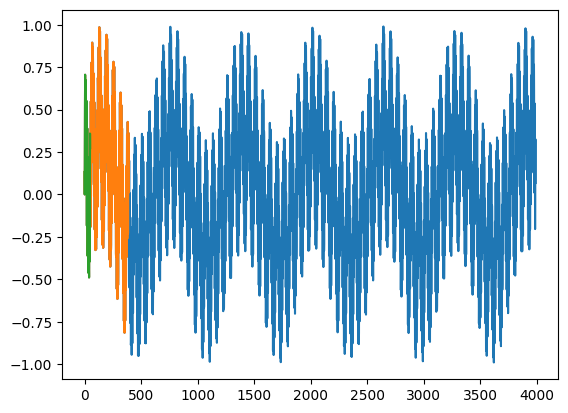

In [ ]:
import pickle

import matplotlib.pyplot as plt
import numpy as np

import FeatureGeneration
#FeatureGeneration.sum_of_sinusoids([0.005, 0.05, .5], tmax=10000, dt=1)
x = FeatureGeneration.timeseries_from_dataset(pickle.load(open(FeatureGeneration.dataset_path("sosdata.pkl"), "rb")))
plt.plot(x[10:4000])
plt.plot(x[10:400])
plt.plot(x[10:60])

K_mode=logarithmic, c=1.138310418863514, τ_0=0.001, τ_47=0.4408120052396712
Using data from /home/fiebig/Dropbox/GIT/BCPNNSim2.2_UC2/tests/UC2-EXTRABRAIN/LTSLtest/general/datasets/sosdata.pkl (timeseries_tmax=20000, requested_tmax=20000)


Hj = 1 nactHi = 48 nsilHi = 0 denHi = 48 Mi = 950 denNi = 45600


paramfile = Parameters.par
taup = 14.112
eps = 7.1e-05
K_mode = logarithmic
TRAINING from simstep = 0 offs = 1
setinputime elapsed = 6.211 sec
TESTING on training data from simstep = 14111
VALIDATING on held-out data from simstep = 28222
TESTING on unseen data from simstep = 30221

GENERATING from simstep = 32220
Total simsteps = 33220, time elapsed = 171.906 sec


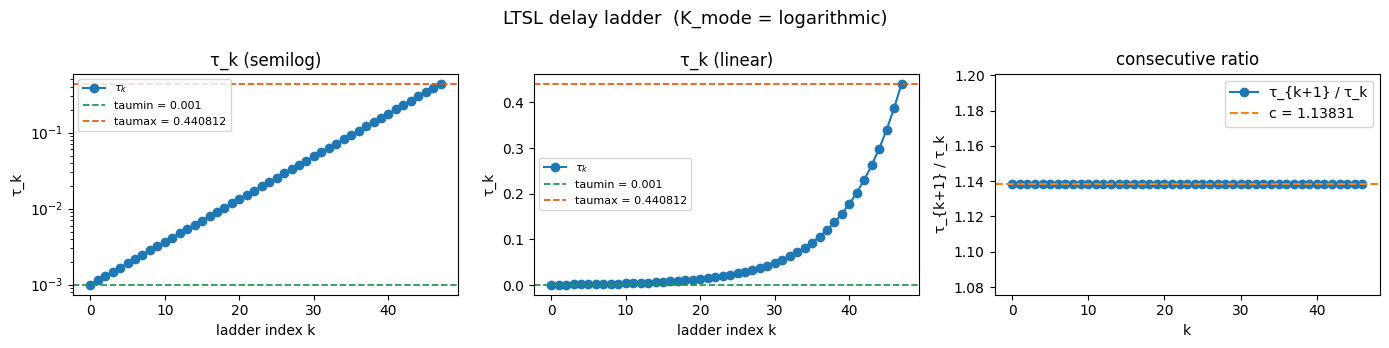

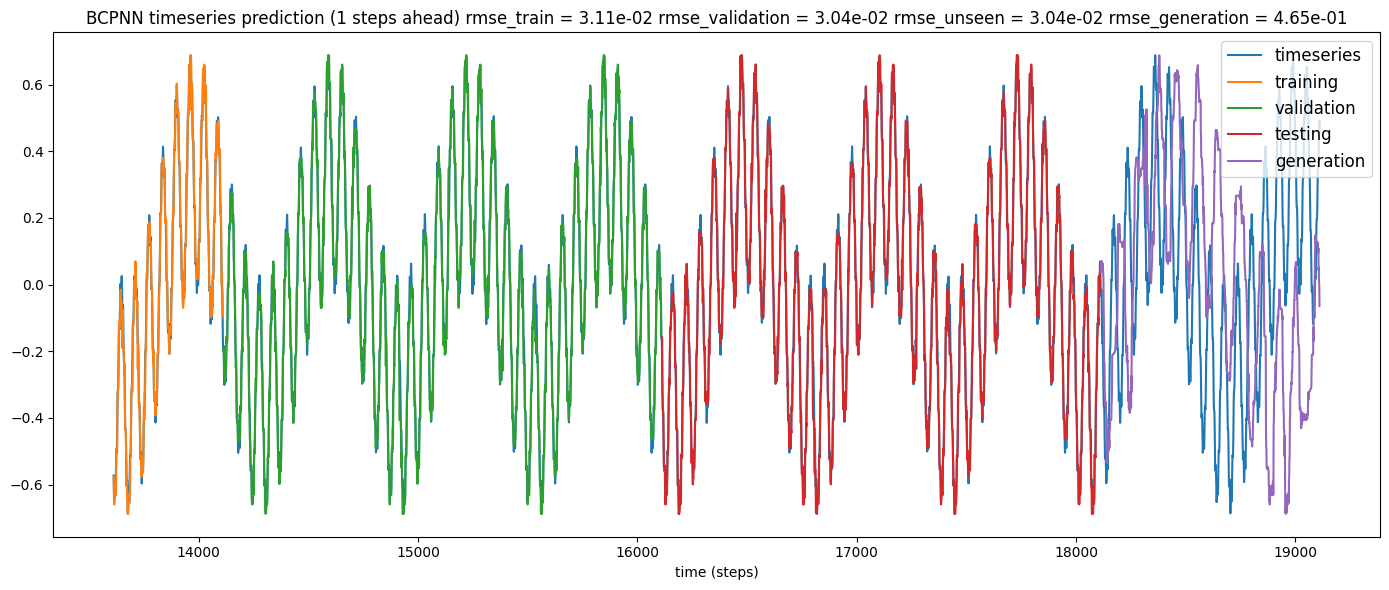

In [5]:
#best for unseen error after 10h search on validation set
"""
=== Best after time budget ===                                                                                 │
  objective      = rmse_validation                                                             │
  K              = 48                                                                          │
  K_mode         = linear                                                                      │
  mean_nbin      = 50                                                                          │
  deriv1st_nbin  = 19                                                                          │
  taumax         = 0.4408120052396719                                                          │
  trnpat         = 14112                                                                       │
  rmse_validation (minimized) = 0.020122602499956482                                           │
  rmse_train     = 0.02045040087629631                                                         │
  rmse_validation = 0.020122602499956482                                                       │
  rmse_unseen    = 0.020662504402670923                                                        │
  rmse_generation = 0.5173575903781014  
"""
import importlib
import Utils, Mains, Display
importlib.reload(Utils)
importlib.reload(Mains)
importlib.reload(Display)
# Load, modify, write
params = Utils.load_params("Parameters_default.par")
params["timeseries_file"] = "sosdata.pkl"#"sosdata.pkl"
params["offs"]     = 1              #1
params["K"]        = 48             #48
params["K_mode"]   = "logarithmic"  #logarithmic
params["mean_nbin"] = 50            #50        
params["deriv1st_nbin"] = 19        #19  
params["taumax"]   = 0.4408120052396719   #0.4408120052396719
params["trnpat"]   = 14112          #up to 150000
params["vanpat"]   = 2000           # 2000 steps for validation
params["tenpat"]   = 2000           #1000
params["ngenstep"] = 1000
Utils.write_params("Parameters.par", params)
fig = Display.plot_ltsl_delay_ladder("Parameters.par", verbose=True)
rmse_train, rmse_validation, rmse_unseen, rmse_generation = Mains.general(figno = 1, verbose=True, data_plot_start=params["trnpat"]-500)

K_mode=logarithmic, c=1.8010381097438874, τ_0=0.001, τ_11=0.6467730687999997
Using data from /home/fiebig/Dropbox/GIT/BCPNNSim2.2_UC2/tests/UC2-EXTRABRAIN/LTSLtest/general/datasets/sosdata.pkl (timeseries_tmax=20000, requested_tmax=20000)


Hj = 1 nactHi = 12 nsilHi = 0 denHi = 12 Mi = 975 denNi = 11700


paramfile = Parameters.par
taup = 5.476
eps = 1.8e-04
K_mode = logarithmic
TRAINING from simstep = 0 offs = 1
setinputime elapsed = 0.984 sec
TESTING on training data from simstep = 5475
VALIDATING on held-out data from simstep = 10950
TESTING on unseen data from simstep = 12549

GENERATING from simstep = 14148
Total simsteps = 15748, time elapsed = 33.129 sec


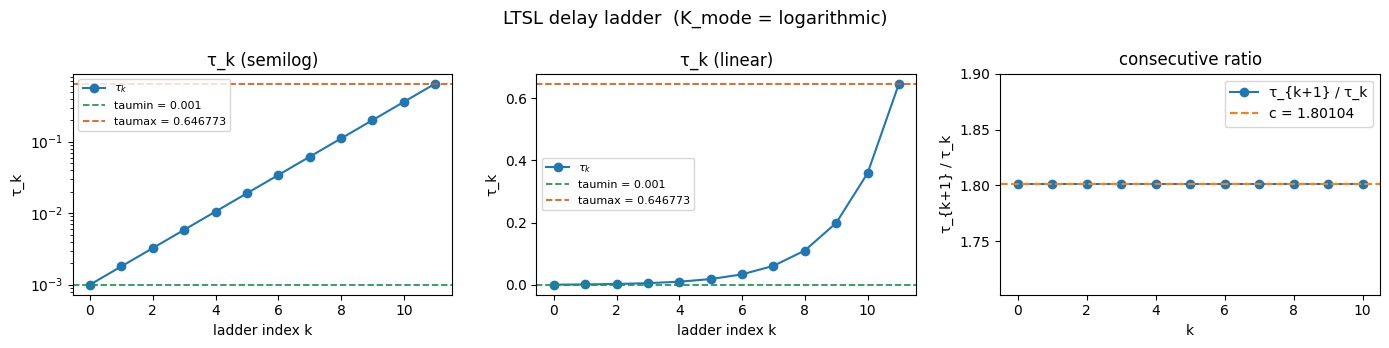

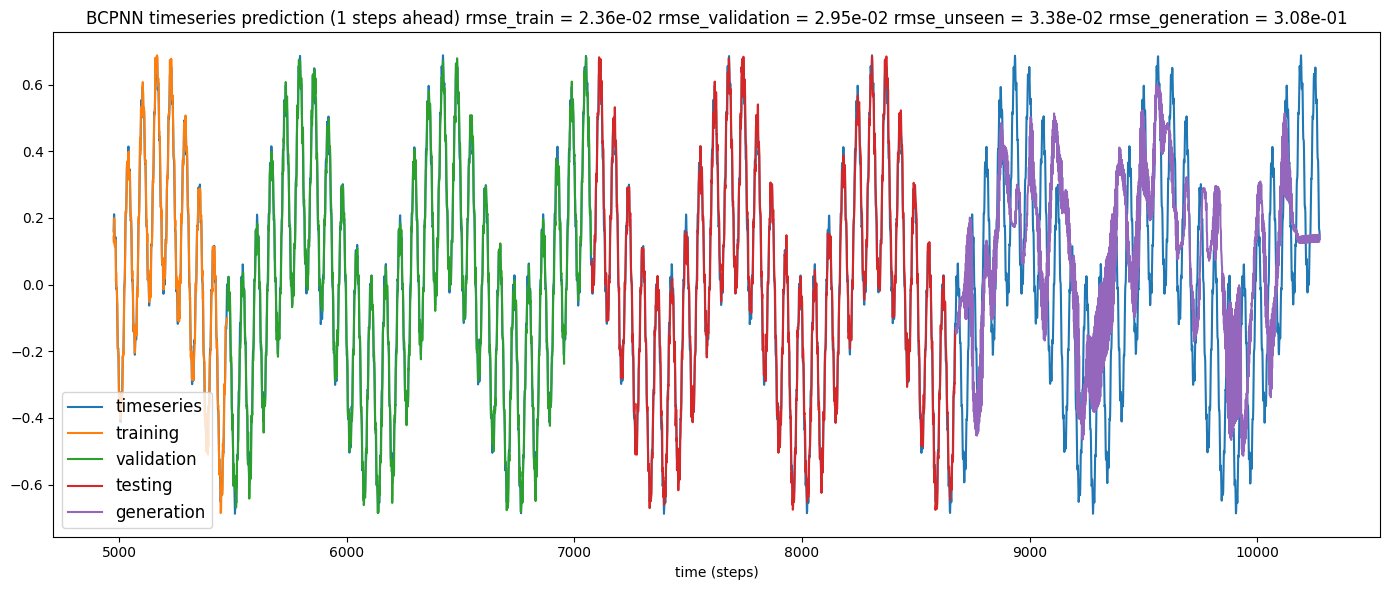

In [4]:
#best for generation after 10h search
"""
=== Best after time budget ===                                                                                 │
  objective      = rmse_generation                                                                             │
  K              = 12                                                                                          │
  K_mode         = logarithmic                                                                                 │
  mean_nbin      = 25                                                                                          │
  deriv1st_nbin  = 39                                                                                          │
  taumax         = 0.6467730688079414                                                                          │
  trnpat         = 5476                                                                                        │
  rmse_generation (minimized) = 0.30768005559720757                                                            │
  rmse_train     = 0.023632397472166222                                                                        │
  rmse_validation = 0.029464516072888844                                                                       │
  rmse_unseen    = 0.03376425483148272                                                                         │
  rmse_generation = 0.30768005559720757  
"""

import importlib
import Utils, Mains, Display
importlib.reload(Utils)
importlib.reload(Mains)
importlib.reload(Display)
# Load, modify, write
params = Utils.load_params("Parameters_default.par")
params["timeseries_file"] = "sosdata.pkl"#"sosdata.pkl"
params["offs"]     = 1              #2
params["K"]        = 12             #12
params["K_mode"]   = "logarithmic"  #logarithmic
params["mean_nbin"] = 25            #25        
params["deriv1st_nbin"] = 39        #7  
params["taumax"]   = 0.6467730688   #0.6467730688079414
params["trnpat"]   = 5476           #5476
params["vanpat"]   = 1600           # 2000 steps for validation
params["tenpat"]   = 1600           #1000
params["ngenstep"] = 1600
Utils.write_params("Parameters.par", params)
fig = Display.plot_ltsl_delay_ladder("Parameters.par", verbose=True)
rmse_train, rmse_validation, rmse_unseen, rmse_generation = Mains.general(figno = 1, verbose=True, data_plot_start=params["trnpat"]-500)

In [ ]:
sweep_spec = { # --- Define parameter values to sweep  ---
   "offs":           [1,2,3,4,5,6,7,8,9,10,20], 
    "K":             [12], #range from evo search: 2-50
    "K_mode":        ["logarithmic"], #new linear mode 
    "mean_nbin":     [25], #range from evo search: 2-100
    "deriv1st_nbin": [39], #range from evo search:  1-16
    "taumax":        [0.65], #range from evo search: 0.00101-1.  
    "trnpat":        [5476], #range from evo search: 500-6000
    "tenpat":        [1000], 
    "vanpat":        [1000], 
    "ngenstep":      [1000]
}
results = Utils.param_sweep(sweep_spec,default_paramfile="Parameters_default.par",paramfile="Parameters.par",run_fn=Mains.general,run_kwargs={"figno": 0, "verbose": False})
Display.plot_sweep_heatmaps(results, sweep_spec, savepath="figs/1_sos_rmse_generation/")

sweep_spec = { # --- Define parameter values to sweep  ---
   "offs":           [1], 
    "K":             [2,3,4,5,6,7,8,10,12,16,32,48,99], #range from evo search: 2-50
    "K_mode":        ["logarithmic"], #new linear mode 
    "mean_nbin":     [25], #range from evo search: 2-100
    "deriv1st_nbin": [39], #range from evo search:  1-16
    "taumax":        [0.65], #range from evo search: 0.00101-1.  
    "trnpat":        [5476], #range from evo search: 500-6000
    "tenpat":        [1000], 
    "vanpat":        [1000], 
    "ngenstep":      [1000]
}
results = Utils.param_sweep(sweep_spec,default_paramfile="Parameters_default.par",paramfile="Parameters.par",run_fn=Mains.general,run_kwargs={"figno": 0, "verbose": False})
Display.plot_sweep_heatmaps(results, sweep_spec, savepath="figs/1_sos_rmse_generation/")

sweep_spec = { # --- Define parameter values to sweep  ---
   "offs":           [1], 
    "K":             [12], #range from evo search: 2-50
    "K_mode":        ["linear","logarithmic"], #new linear mode 
    "mean_nbin":     [25], #range from evo search: 2-100
    "deriv1st_nbin": [39], #range from evo search:  1-16
    "taumax":        [0.65], #range from evo search: 0.00101-1.  
    "trnpat":        [5476], #range from evo search: 500-6000
    "tenpat":        [1000], 
    "vanpat":        [1000], 
    "ngenstep":      [1000]
}
results = Utils.param_sweep(sweep_spec,default_paramfile="Parameters_default.par",paramfile="Parameters.par",run_fn=Mains.general,run_kwargs={"figno": 0, "verbose": False})
Display.plot_sweep_heatmaps(results, sweep_spec, savepath="figs/1_sos_rmse_generation/")

sweep_spec = { # --- Define parameter values to sweep  ---
   "offs":           [1], 
    "K":             [12], #range from evo search: 2-50
    "K_mode":        ["logarithmic"], #new linear mode 
    "mean_nbin":     [2,4,8,16,25,32,64,100], #range from evo search: 2-100
    "deriv1st_nbin": [39], #range from evo search:  1-16
    "taumax":        [0.65], #range from evo search: 0.00101-1.  
    "trnpat":        [5476], #range from evo search: 500-6000
    "tenpat":        [1000], 
    "vanpat":        [1000], 
    "ngenstep":      [1000]
}
results = Utils.param_sweep(sweep_spec,default_paramfile="Parameters_default.par",paramfile="Parameters.par",run_fn=Mains.general,run_kwargs={"figno": 0, "verbose": False})
Display.plot_sweep_heatmaps(results, sweep_spec, savepath="figs/1_sos_rmse_generation/")

sweep_spec = { # --- Define parameter values to sweep  ---
   "offs":           [1], 
    "K":             [12], #range from evo search: 2-50
    "K_mode":        ["logarithmic"], #new linear mode 
    "mean_nbin":     [25], #range from evo search: 2-100
    "deriv1st_nbin": [2,4,6,8,16,32,64,100], #range from evo search:  1-16
    "taumax":        [0.65], #range from evo search: 0.00101-1.  
    "trnpat":        [5476], #range from evo search: 500-6000
    "tenpat":        [1000], 
    "vanpat":        [1000], 
    "ngenstep":      [1000]
}
results = Utils.param_sweep(sweep_spec,default_paramfile="Parameters_default.par",paramfile="Parameters.par",run_fn=Mains.general,run_kwargs={"figno": 0, "verbose": False})
Display.plot_sweep_heatmaps(results, sweep_spec, savepath="figs/1_sos_rmse_generation/")

sweep_spec = { # --- Define parameter values to sweep  ---
   "offs":           [1], 
    "K":             [12], #range from evo search: 2-50
    "K_mode":        ["logarithmic"], #new linear mode 
    "mean_nbin":     [25], #range from evo search: 2-100
    "deriv1st_nbin": [39], #range from evo search:  1-16
    "taumax":        [0.0011,0.002,0.005,0.01,0.02,0.05,0.1,0.2,0.44,0.5,0.65,0.8,1], #range from evo search: 0.00101-1.  
    "tenpat":        [1000], 
    "vanpat":        [1000], 
    "ngenstep":      [1000]
}
results = Utils.param_sweep(sweep_spec,default_paramfile="Parameters_default.par",paramfile="Parameters.par",run_fn=Mains.general,run_kwargs={"figno": 0, "verbose": False})
Display.plot_sweep_heatmaps(results, sweep_spec, savepath="figs/1_sos_rmse_generation/")

sweep_spec = { # --- Define parameter values to sweep  ---
   "offs":           [1], 
    "K":             [12], #range from evo search: 2-50
    "K_mode":        ["logarithmic"], #new linear mode 
    "mean_nbin":     [25], #range from evo search: 2-100
    "deriv1st_nbin": [39], #range from evo search:  1-16
    "taumax":        [0.65], #range from evo search: 0.00101-1.  
    "trnpat":        [500,1000,3000,5476,9000,13000], #range from evo search: 500-6000
    "tenpat":        [1000], 
    "vanpat":        [1000], 
    "ngenstep":      [1000]
}
results = Utils.param_sweep(sweep_spec,default_paramfile="Parameters_default.par",paramfile="Parameters.par",run_fn=Mains.general,run_kwargs={"figno": 0, "verbose": False})
Display.plot_sweep_heatmaps(results, sweep_spec, savepath="figs/1_sos_rmse_generation/")